# Software Engineering in the era of GenAI: A Survey from Industry

In [14]:
# =========================
# Imports
# =========================
import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Optional: text analysis (later)
from wordcloud import WordCloud


# =========================
# Plot defaults
# =========================
sns.set_context("talk")      # readable plots
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


# =========================
# Global variables
# =========================
# Change this to the location of your Excel file
DATASET_PATH = Path("data/Survey_SoftwareDevelopmentInEraGenAI_polished.xlsx")

# Will hold loaded workbook data in memory:
# - RAW_SHEETS: dict[sheet_name] -> DataFrame (raw, header=None)
# - COMPLETE_DF: DataFrame for sheet 'complete' if present
RAW_SHEETS = {}
COMPLETE_DF = None


# =========================
# Data loading
# =========================
def load_workbook(path: Path = DATASET_PATH) -> None:
    """
    Loads all sheets into the global dict RAW_SHEETS with header=None
    and sets COMPLETE_DF if 'complete' exists.

    Sheets are kept raw to respect your custom structure:
    - Standard Q sheets: row0=question title, data starts row1
    - Scaling Q sheets: row0=question title, row1=scale labels, data starts row2
    """
    global RAW_SHEETS, COMPLETE_DF

    if not path.exists():
        raise FileNotFoundError(f"Excel file not found: {path.resolve()}")

    xls = pd.ExcelFile(path)
    RAW_SHEETS = {name: pd.read_excel(path, sheet_name=name, header=None) for name in xls.sheet_names}

    COMPLETE_DF = RAW_SHEETS.get("complete", None)


# =========================
# Extraction helpers
# =========================
def get_standard_answer(sheet_name: str, respondent_id: int):
    """
    For Q01–Q09; Q11–Q13; Q16–Q23
    Structure:
      - col0 = ID
      - col1 = answer
      - row0 is question title
      - responses start from row1
    """
    if sheet_name not in RAW_SHEETS:
        raise KeyError(f"Sheet '{sheet_name}' not loaded.")

    df = RAW_SHEETS[sheet_name]
    responses = df.iloc[1:].copy()
    match = responses[responses[0] == respondent_id]
    if match.empty:
        return None
    return match.iloc[0, 1]


def parse_multichoice(raw_answer):
    """
    Parses semicolon-separated multi-choice answers.
    - Trims whitespace
    - Drops empty items (e.g., trailing ';')
    """
    if pd.isna(raw_answer) or raw_answer is None:
        return []
    parts = [p.strip() for p in str(raw_answer).split(";")]
    return [p for p in parts if p]  # remove empty strings


def get_scaling_answers(sheet_name: str, respondent_id: int) -> dict | None:
    """
    For Q10, Q14 (scaling matrices)
    Structure:
      - row0: question title
      - row1: headers for columns 1..N (scale statements/categories)
      - rows 2..: responses (col0 is ID)
    Returns a dict of {header: response_value}
    """
    if sheet_name not in RAW_SHEETS:
        raise KeyError(f"Sheet '{sheet_name}' not loaded.")

    df = RAW_SHEETS[sheet_name]

    # headers in row1, columns 1..end
    headers = df.iloc[1, 1:].tolist()

    # responses start row2
    resp = df.iloc[2:].copy()
    resp.columns = ["ID"] + headers

    row = resp[resp["ID"] == respondent_id]
    if row.empty:
        return None

    # return all columns except ID
    out = row.iloc[0, 1:].to_dict()
    # Convert NaN to None for nicer printing
    out = {k: (None if pd.isna(v) else v) for k, v in out.items()}
    return out


# =========================
# Validation function (your Step 1 checks)
# =========================
def run_validation_checks() -> dict:
    """
    Implements your specified validation outputs:
      - Q10: id=3 and id=24
      - Q08: id=2
      - Q23: id=6
      - Q16: id=14 (multi-choice parsing check)
    Returns a dict with results.
    """
    results = {}

    # Q10 scaling
    results["Q10_id_3"] = get_scaling_answers("Q10", 3)
    results["Q10_id_24"] = get_scaling_answers("Q10", 24)

    # # Q08 standard
    results["Q08_id_2_raw"] = get_standard_answer("Q08", 2)

    # # Q23 standard (open-ended)
    results["Q23_id_6_raw"] = get_standard_answer("Q23", 6)

    # # Q16 multi-choice parse
    q16_raw = get_standard_answer("Q16", 14)
    results["Q16_id_14_raw"] = q16_raw
    results["Q16_id_14_parsed"] = parse_multichoice(q16_raw)

    return results

In [16]:
# Validation: comment the code below in case all is good.

# load_workbook(DATASET_PATH)

# RAW_SHEETS["Q10"].head(3)

# validation = run_validation_checks()
# validation

In [17]:
# =========================
# Pie chart utility for single-choice categorical questions
# =========================
from __future__ import annotations

from typing import Optional, Union, Dict
import pandas as pd
import matplotlib.pyplot as plt


def plot_single_choice_pie(
    series: pd.Series,
    *,
    title: str,
    dropna: bool = True,
    na_label: str = "No answer",
    normalize: bool = True,
    min_pct_to_label: float = 3.0,
    max_categories: Optional[int] = None,
    other_label: str = "Other",
    sort: str = "desc",  # "desc" | "asc" | "none"
    startangle: int = 90
) -> pd.DataFrame:
    """
    Plot a pie chart for a single-choice categorical question.

    Parameters
    ----------
    series:
        A pandas Series of responses (one response per participant).
    title:
        Chart title.
    dropna:
        If True, omit missing answers. If False, include them as `na_label`.
    na_label:
        Label for missing answers when dropna=False.
    normalize:
        If True, show percentages. If False, show counts in labels.
    min_pct_to_label:
        Only show slice labels for categories whose percentage >= this value.
    max_categories:
        If set, keep only the top N categories by count and group the rest into `other_label`.
    other_label:
        Label used for grouped remainder categories.
    sort:
        Sort order for categories: "desc", "asc", or "none".
    startangle:
        Starting angle for the pie chart.

    Returns
    -------
    A DataFrame with columns: ['category', 'count', 'pct'] used to plot the chart.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series.")

    # Clean / standardize values
    s = series.copy()

    # Convert non-null to string and strip whitespace
    s = s.apply(lambda x: str(x).strip() if pd.notna(x) else x)

    if dropna:
        s = s.dropna()
    else:
        s = s.fillna(na_label)

    # If everything is empty after dropna
    if s.empty:
        raise ValueError("No data to plot (series is empty after handling missing values).")

    # Counts
    counts = s.value_counts(dropna=False)

    # Optionally group small categories into "Other" by limiting to top N
    if max_categories is not None and max_categories > 0 and len(counts) > max_categories:
        top = counts.iloc[:max_categories]
        rest_sum = counts.iloc[max_categories:].sum()
        counts = pd.concat([top, pd.Series({other_label: rest_sum})])

    # Optional sort
    if sort == "asc":
        counts = counts.sort_values(ascending=True)
    elif sort == "desc":
        counts = counts.sort_values(ascending=False)
    elif sort == "none":
        pass
    else:
        raise ValueError("sort must be one of: 'desc', 'asc', 'none'.")

    total = counts.sum()
    pct = (counts / total * 100).round(2)

    plot_df = pd.DataFrame(
        {"category": counts.index.astype(str), "count": counts.values, "pct": pct.values}
    )

    # Label function: show only if >= min_pct_to_label
    def _autopct(p: float) -> str:
        if p < min_pct_to_label:
            return ""
        if normalize:
            return f"{p:.1f}%"
        # When normalize=False, show count instead of percent
        # Convert percent back to count (robust rounding)
        c = int(round(p / 100 * total))
        return str(c)

    fig, ax = plt.subplots()

    ax.pie(
        plot_df["count"],
        labels=plot_df["category"],
        autopct=_autopct,
        startangle=startangle
    )
    ax.set_title(title)
    ax.axis("equal")  # perfect circle

    # Optional legend with count + percent (helps when labels are suppressed)
    legend_labels = [
        f"{row.category} — {row.count} ({row.pct:.1f}%)"
        for row in plot_df.itertuples(index=False)
    ]
    ax.legend(
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    return plot_df


# =========================
# Convenience wrapper: plot directly from a "standard" Q-sheet
# (Q01–Q09; Q11–Q13; Q16–Q23 where column 1 is the response)
# =========================
def plot_pie_from_standard_sheet(
    raw_sheets: Dict[str, pd.DataFrame],
    sheet_name: str,
    *,
    title: str,
    dropna: bool = True,
    na_label: str = "No answer",
    max_categories: Optional[int] = None,
    other_label: str = "Other",
    min_pct_to_label: float = 3.0,
    sort: str = "desc"
) -> pd.DataFrame:
    """
    For your survey structure: first row is question title, responses start from row 1.
    Column 0 = respondent ID, Column 1 = answer.
    """
    if sheet_name not in raw_sheets:
        raise KeyError(f"Sheet '{sheet_name}' not found in raw_sheets.")

    df = raw_sheets[sheet_name]
    responses = df.iloc[1:, 1]  # row1.., col1

    return plot_single_choice_pie(
        responses,
        title=title,
        dropna=dropna,
        na_label=na_label,
        max_categories=max_categories,
        other_label=other_label,
        min_pct_to_label=min_pct_to_label,
        sort=sort
    )

In [18]:
# =========================
# Multi-choice visualization utilities
# (semicolon-separated answers in a single cell)
# =========================
from __future__ import annotations

from typing import Optional, Dict, List, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_multichoice_series(
    series: pd.Series,
    *,
    sep: str = ";",
    dropna: bool = True,
    strip: bool = True,
    lowercase: bool = False,
    drop_empty: bool = True,
) -> pd.Series:
    """
    Convert a multi-choice response series (semicolon-separated strings) into a long Series
    where each selected option becomes one row.

    Returns
    -------
    A "long" Series of individual options. Example:
      ["Python;Java", "Python"] -> ["Python", "Java", "Python"]
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    s = series.copy()

    if dropna:
        s = s.dropna()
    else:
        s = s.fillna("")

    def _split_cell(x) -> List[str]:
        if pd.isna(x):
            return []
        txt = str(x)
        parts = txt.split(sep)
        if strip:
            parts = [p.strip() for p in parts]
        if lowercase:
            parts = [p.lower() for p in parts]
        if drop_empty:
            parts = [p for p in parts if p]
        return parts

    exploded = s.apply(_split_cell).explode()
    exploded = exploded.dropna()
    if drop_empty:
        exploded = exploded[exploded.astype(str).str.len() > 0]

    return exploded


def multichoice_counts(
    series: pd.Series,
    *,
    sep: str = ";",
    dropna: bool = True,
    strip: bool = True,
    lowercase: bool = False,
    drop_empty: bool = True,
    max_categories: Optional[int] = None,
    other_label: str = "Other",
    sort: str = "desc",  # "desc" | "asc" | "none"
) -> pd.DataFrame:
    """
    Compute counts & percentages for multi-choice series.

    Notes
    -----
    - 'pct_of_respondents' counts how many respondents selected the option / total respondents.
    - This requires knowing total respondent count, including those who answered nothing or NaN (depending on dropna).
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    # Total respondents baseline
    if dropna:
        respondent_total = series.dropna().shape[0]
    else:
        respondent_total = series.shape[0]

    # Long/exploded selections
    long = parse_multichoice_series(
        series,
        sep=sep,
        dropna=dropna,
        strip=strip,
        lowercase=lowercase,
        drop_empty=drop_empty,
    )

    # If nobody selected anything
    if long.empty:
        return pd.DataFrame(columns=["option", "count", "pct_of_respondents"])

    counts = long.value_counts()

    # Optionally group into top N + Other
    if max_categories is not None and max_categories > 0 and len(counts) > max_categories:
        top = counts.iloc[:max_categories]
        rest_sum = counts.iloc[max_categories:].sum()
        counts = pd.concat([top, pd.Series({other_label: rest_sum})])

    # Sort
    if sort == "asc":
        counts = counts.sort_values(ascending=True)
    elif sort == "desc":
        counts = counts.sort_values(ascending=False)
    elif sort == "none":
        pass
    else:
        raise ValueError("sort must be one of: 'desc', 'asc', 'none'.")

    df = pd.DataFrame(
        {
            "option": counts.index.astype(str),
            "count": counts.values,
            "pct_of_respondents": (counts.values / max(respondent_total, 1) * 100),
        }
    )
    return df


def plot_multichoice_bar(
    series: pd.Series,
    *,
    title: str,
    sep: str = ";",
    dropna: bool = True,
    strip: bool = True,
    lowercase: bool = False,
    drop_empty: bool = True,
    max_categories: Optional[int] = 15,
    other_label: str = "Other",
    sort: str = "desc",  # "desc" | "asc" | "none"
    orientation: str = "h",  # "h" (recommended) or "v"
    show_values: bool = True,
    value_mode: str = "pct",  # "pct" or "count"
) -> pd.DataFrame:
    """
    Plot a bar chart for a multiple-choice categorical question.

    Bars represent:
      - count of selections per option
      - and optionally label with percentage of respondents or raw count

    Returns
    -------
    DataFrame used to plot: ['option', 'count', 'pct_of_respondents']
    """
    df = multichoice_counts(
        series,
        sep=sep,
        dropna=dropna,
        strip=strip,
        lowercase=lowercase,
        drop_empty=drop_empty,
        max_categories=max_categories,
        other_label=other_label,
        sort=sort,
    )

    if df.empty:
        raise ValueError("No multi-choice selections found to plot.")

    fig, ax = plt.subplots()

    if orientation == "h":
        ax.barh(df["option"], df["count"])
        ax.invert_yaxis()  # highest on top
        ax.set_xlabel("Selections (count)")
        ax.set_ylabel("")
    elif orientation == "v":
        ax.bar(df["option"], df["count"])
        ax.set_ylabel("Selections (count)")
        ax.set_xlabel("")
        plt.xticks(rotation=45, ha="right")
    else:
        raise ValueError("orientation must be 'h' or 'v'.")

    ax.set_title(title)

    # Add text labels
    if show_values:
        for i, row in enumerate(df.itertuples(index=False)):
            label = f"{row.pct_of_respondents:.1f}%" if value_mode == "pct" else f"{int(row.count)}"
            if orientation == "h":
                ax.text(row.count, i, f" {label}", va="center")
            else:
                ax.text(i, row.count, f"{label}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    return df


def plot_multichoice_heatmap_onehot(
    series: pd.Series,
    *,
    title: str,
    sep: str = ";",
    dropna: bool = True,
    strip: bool = True,
    lowercase: bool = False,
    drop_empty: bool = True,
    max_options: Optional[int] = 30,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    OPTIONAL (advanced): one-hot encode multi-choice selections and display as a heatmap
    (respondents x options). This is useful for exploring patterns, but can be busy.

    Returns
    -------
    (onehot_df, option_summary_df)
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    # Keep respondent index to build row-wise one-hot
    base = series.copy()
    if dropna:
        base = base.dropna()

    # Parse per respondent into list
    def _to_list(x):
        if pd.isna(x):
            return []
        parts = str(x).split(sep)
        if strip:
            parts = [p.strip() for p in parts]
        if lowercase:
            parts = [p.lower() for p in parts]
        if drop_empty:
            parts = [p for p in parts if p]
        return parts

    lists = base.apply(_to_list)

    # Build vocabulary of options (optionally cap to max_options by frequency)
    long = lists.explode()
    long = long.dropna()
    if drop_empty:
        long = long[long.astype(str).str.len() > 0]

    if long.empty:
        raise ValueError("No multi-choice selections found to encode.")

    freq = long.value_counts()
    if max_options is not None and max_options > 0 and len(freq) > max_options:
        vocab = freq.index[:max_options].tolist()
    else:
        vocab = freq.index.tolist()

    # One-hot
    onehot = pd.DataFrame(0, index=lists.index, columns=vocab, dtype=int)
    for ridx, opts in lists.items():
        for opt in opts:
            if opt in onehot.columns:
                onehot.loc[ridx, opt] = 1

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, max(6, 0.3 * onehot.shape[0])))
    im = ax.imshow(onehot.values, aspect="auto")

    ax.set_title(title)
    ax.set_yticks(range(onehot.shape[0]))
    ax.set_yticklabels(onehot.index.astype(str))
    ax.set_xticks(range(onehot.shape[1]))
    ax.set_xticklabels(onehot.columns, rotation=45, ha="right")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    option_summary = pd.DataFrame(
        {"option": freq.index.astype(str), "count": freq.values}
    )

    return onehot, option_summary


# =========================
# Convenience wrapper: plot directly from a "standard" Q-sheet
# (col0=id, col1=semicolon-separated answer; row0=title; data starts row1)
# =========================
def plot_multichoice_from_standard_sheet(
    raw_sheets: Dict[str, pd.DataFrame],
    sheet_name: str,
    *,
    title: str,
    sep: str = ";",
    dropna: bool = True,
    max_categories: Optional[int] = 15,
    other_label: str = "Other",
    orientation: str = "h",
    show_values: bool = True,
    value_mode: str = "pct",
) -> pd.DataFrame:
    if sheet_name not in raw_sheets:
        raise KeyError(f"Sheet '{sheet_name}' not found in raw_sheets.")

    df = raw_sheets[sheet_name]
    responses = df.iloc[1:, 1]  # row1.., col1
    return plot_multichoice_bar(
        responses,
        title=title,
        sep=sep,
        dropna=dropna,
        max_categories=max_categories,
        other_label=other_label,
        orientation=orientation,
        show_values=show_values,
        value_mode=value_mode,
    )

In [19]:
# =========================
# Scaling (matrix/Likert) visualization utilities
# For sheets like Q10, Q14:
#   row0 = question title
#   row1 = column headers (items/tasks)
#   rows 2.. = responses (col0=ID)
# =========================
from __future__ import annotations

from typing import Dict, Optional, List, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_scaling_sheet_long(
    df_raw: pd.DataFrame,
    *,
    sheet_name: str = "",
    id_col_name: str = "ID",
    start_row: int = 2,
    header_row: int = 1,
    id_col_index: int = 0,
    dropna_responses: bool = True,
) -> pd.DataFrame:
    """
    Convert a raw scaling sheet (header=None) into LONG format:
      columns: [ID, item, response]

    Parameters reflect your layout:
      - header_row=1: row containing item/task names (starting from col 1)
      - start_row=2: first row containing responses
      - id_col_index=0: first column is respondent ID
    """
    if not isinstance(df_raw, pd.DataFrame):
        raise TypeError("df_raw must be a pandas DataFrame")

    if df_raw.shape[0] <= start_row:
        raise ValueError(f"'{sheet_name}' does not have enough rows to parse as scaling sheet.")

    headers = df_raw.iloc[header_row, 1:].tolist()  # items/tasks
    resp = df_raw.iloc[start_row:, :].copy()

    resp.columns = [id_col_name] + headers
    long = resp.melt(id_vars=[id_col_name], var_name="item", value_name="response")

    if dropna_responses:
        long = long.dropna(subset=["response"])

    # Clean strings
    long["item"] = long["item"].astype(str).str.strip()
    long["response"] = long["response"].apply(lambda x: str(x).strip() if pd.notna(x) else x)

    if sheet_name:
        long.insert(0, "sheet", sheet_name)

    return long


def map_likert_to_numeric(
    series: pd.Series,
    *,
    mapping: Dict[str, Union[int, float]],
    unknown_to_nan: bool = True,
) -> pd.Series:
    """
    Map Likert text categories to numeric scores using a provided mapping dict.

    Example mapping:
      {
        "Not Applicable": np.nan,
        "Not Useful": 1,
        "Slightly Useful": 2,
        "Somewhat Useful": 3,
        "Very Useful": 4,
        "Essential": 5
      }
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    s = series.copy().astype(str).str.strip()

    out = s.map(mapping)
    if unknown_to_nan:
        # unmapped values become NaN
        return out
    # keep original if unmapped
    return out.where(out.notna(), s)


def scaling_item_summary(
    long_df: pd.DataFrame,
    *,
    response_order: Optional[List[str]] = None,
    likert_mapping: Optional[Dict[str, Union[int, float]]] = None,
    include_numeric_summary: bool = True,
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
    """
    Produce:
      1) Distribution table: counts and percentages per item x response
      2) Optional numeric summary per item: mean/median/std/n (if mapping provided)

    Returns (dist_df, numeric_df_or_none)

    dist_df columns: item, response, count, pct_of_item
    numeric_df columns: item, n, mean, median, std
    """
    req_cols = {"ID", "item", "response"}
    if not req_cols.issubset(long_df.columns):
        raise ValueError(f"long_df must contain columns {req_cols}")

    # Counts per item/response
    c = (
        long_df.groupby(["item", "response"], dropna=False)
        .size()
        .reset_index(name="count")
    )

    # pct within each item
    c["pct_of_item"] = c.groupby("item")["count"].transform(lambda x: x / x.sum() * 100)

    # Optional ordering for responses
    if response_order is not None:
        c["response"] = pd.Categorical(c["response"], categories=response_order, ordered=True)
        c = c.sort_values(["item", "response"])

    numeric_df = None
    if include_numeric_summary and likert_mapping is not None:
        tmp = long_df.copy()
        tmp["score"] = map_likert_to_numeric(tmp["response"], mapping=likert_mapping)
        # drop NaN scores (e.g., Not Applicable)
        tmp = tmp.dropna(subset=["score"])
        numeric_df = (
            tmp.groupby("item")["score"]
            .agg(n="count", mean="mean", median="median", std="std")
            .reset_index()
        )

    return c, numeric_df


def plot_scaling_distribution_stacked_bar(
    long_df: pd.DataFrame,
    *,
    title: str,
    response_order: List[str],
    min_pct_to_label: float = 5.0,
    max_items: Optional[int] = None,
    sort_items_by: str = "mean",  # "mean" | "median" | "topbox" | "none"
    likert_mapping: Optional[Dict[str, Union[int, float]]] = None,
    topbox_responses: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (12, 8),
) -> pd.DataFrame:
    """
    Plot stacked bar chart (Likert-style) showing % distribution per item.

    - response_order controls stack order left->right.
    - sort_items_by:
        * mean/median requires likert_mapping
        * topbox requires topbox_responses list
    Returns distribution DataFrame used for plotting (wide, %).
    """
    dist_df, numeric_df = scaling_item_summary(
        long_df,
        response_order=response_order,
        likert_mapping=likert_mapping,
        include_numeric_summary=True,
    )

    # Build wide % table: rows=item, cols=response, values=pct
    wide = dist_df.pivot_table(index="item", columns="response", values="pct_of_item", fill_value=0.0)
    # Ensure all response columns exist in correct order
    for r in response_order:
        if r not in wide.columns:
            wide[r] = 0.0
    wide = wide[response_order]

    # Sort items
    wide_sorted = wide.copy()

    if sort_items_by == "none":
        pass
    elif sort_items_by in {"mean", "median"}:
        if numeric_df is None:
            raise ValueError("To sort by mean/median, provide likert_mapping.")
        metric = sort_items_by
        order = numeric_df.sort_values(metric, ascending=False)["item"]
        wide_sorted = wide_sorted.loc[order]
    elif sort_items_by == "topbox":
        if not topbox_responses:
            raise ValueError("topbox_responses must be provided when sort_items_by='topbox'.")
        missing = [r for r in topbox_responses if r not in wide_sorted.columns]
        if missing:
            raise ValueError(f"topbox_responses not present in data columns: {missing}")
        wide_sorted["__topbox__"] = wide_sorted[topbox_responses].sum(axis=1)
        wide_sorted = wide_sorted.sort_values("__topbox__", ascending=False).drop(columns="__topbox__")
    else:
        raise ValueError("sort_items_by must be one of: 'mean', 'median', 'topbox', 'none'.")

    # Limit items
    if max_items is not None and max_items > 0 and len(wide_sorted) > max_items:
        wide_sorted = wide_sorted.iloc[:max_items]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    left = np.zeros(len(wide_sorted))
    y = np.arange(len(wide_sorted))
    items = wide_sorted.index.tolist()

    for resp in response_order:
        vals = wide_sorted[resp].values
        bars = ax.barh(y, vals, left=left, label=str(resp))
        # Label slices if big enough
        for i, v in enumerate(vals):
            if v >= min_pct_to_label:
                ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=10)
        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(items)
    ax.invert_yaxis()
    ax.set_xlabel("Percent of responses per item")
    ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()

    return wide_sorted.reset_index().rename(columns={"item": "item"})


def plot_scaling_item_means(
    long_df: pd.DataFrame,
    *,
    title: str,
    likert_mapping: Dict[str, Union[int, float]],
    drop_unmapped: bool = True,
    max_items: Optional[int] = None,
    sort_desc: bool = True,
    figsize: Tuple[int, int] = (12, 8),
) -> pd.DataFrame:
    """
    Plot mean score per item (requires likert_mapping).
    Useful for a compact ranking view (but note Likert is ordinal; interpret carefully).

    Returns numeric summary DataFrame.
    """
    tmp = long_df.copy()
    tmp["score"] = map_likert_to_numeric(tmp["response"], mapping=likert_mapping)
    if drop_unmapped:
        tmp = tmp.dropna(subset=["score"])

    summary = (
        tmp.groupby("item")["score"]
        .agg(n="count", mean="mean", median="median", std="std")
        .reset_index()
    )

    if sort_desc:
        summary = summary.sort_values("mean", ascending=False)

    if max_items is not None and max_items > 0 and len(summary) > max_items:
        summary = summary.iloc[:max_items]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(summary["item"], summary["mean"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Mean score")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    return summary


# =========================
# Convenience wrapper: plot directly from RAW_SHEETS
# =========================
def plot_scaling_from_raw_sheet(
    raw_sheets: Dict[str, pd.DataFrame],
    sheet_name: str,
    *,
    title: Optional[str] = None,
    response_order: Optional[List[str]] = None,
    likert_mapping: Optional[Dict[str, Union[int, float]]] = None,
    kind: str = "stacked",  # "stacked" | "means"
    max_items: Optional[int] = None,
    min_pct_to_label: float = 5.0,
    sort_items_by: str = "mean",
    topbox_responses: Optional[List[str]] = None,
) -> Union[pd.DataFrame, Tuple[pd.DataFrame, Optional[pd.DataFrame]]]:
    """
    High-level plotting entrypoint for scaling questions.

    kind="stacked":
      - response_order is required
    kind="means":
      - likert_mapping is required
    """
    if sheet_name not in raw_sheets:
        raise KeyError(f"Sheet '{sheet_name}' not found in raw_sheets.")

    df_raw = raw_sheets[sheet_name]
    long = load_scaling_sheet_long(df_raw, sheet_name=sheet_name)

    plot_title = title if title is not None else f"{sheet_name} — Scaling question"

    if kind == "stacked":
        if response_order is None:
            raise ValueError("response_order is required for kind='stacked'.")
        return plot_scaling_distribution_stacked_bar(
            long,
            title=plot_title,
            response_order=response_order,
            min_pct_to_label=min_pct_to_label,
            max_items=max_items,
            sort_items_by=sort_items_by,
            likert_mapping=likert_mapping,
            topbox_responses=topbox_responses,
        )
    elif kind == "means":
        if likert_mapping is None:
            raise ValueError("likert_mapping is required for kind='means'.")
        return plot_scaling_item_means(
            long,
            title=plot_title,
            likert_mapping=likert_mapping,
            max_items=max_items,
        )
    else:
        raise ValueError("kind must be 'stacked' or 'means'.")

In [20]:
# =========================
# General statistical analysis toolkit for survey questions
# Works for:
#  - single-choice categorical (Chi-square, Cramér's V)
#  - multi-choice categorical (option-level 2x2 tests, Fisher/Chi-square, effect size)
#  - scaling/Likert (group comparisons: Mann–Whitney, Kruskal–Wallis; Spearman correlation)
# =========================
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Union, Literal

import numpy as np
import pandas as pd
from scipy import stats


# -------------------------
# Helpers: cleaning + types
# -------------------------
def _clean_cat_series(s: pd.Series, dropna: bool = True, na_label: str = "No answer") -> pd.Series:
    s = s.copy()
    s = s.apply(lambda x: str(x).strip() if pd.notna(x) else x)
    if dropna:
        s = s.dropna()
    else:
        s = s.fillna(na_label)
    # Drop empty strings after stripping (often from messy exports)
    s = s[s.astype(str).str.len() > 0]
    return s


def _parse_multichoice_cell(
    x,
    sep: str = ";",
    strip: bool = True,
    drop_empty: bool = True,
) -> List[str]:
    if pd.isna(x) or x is None:
        return []
    parts = str(x).split(sep)
    if strip:
        parts = [p.strip() for p in parts]
    if drop_empty:
        parts = [p for p in parts if p]
    return parts


def multichoice_to_onehot(
    series: pd.Series,
    *,
    sep: str = ";",
    dropna: bool = True,
    strip: bool = True,
    drop_empty: bool = True,
    max_options: Optional[int] = None,
) -> pd.DataFrame:
    """
    One-hot encode a multi-choice series into a DataFrame:
      rows = respondents (index kept)
      cols = options
      values = 0/1

    If max_options is set, keeps only top-N most frequent options.
    """
    base = series.copy()
    if dropna:
        base = base.dropna()

    lists = base.apply(lambda x: _parse_multichoice_cell(x, sep=sep, strip=strip, drop_empty=drop_empty))

    long = lists.explode().dropna()
    if drop_empty:
        long = long[long.astype(str).str.len() > 0]

    if long.empty:
        return pd.DataFrame(index=base.index)

    freq = long.value_counts()

    if max_options is not None and max_options > 0 and len(freq) > max_options:
        vocab = freq.index[:max_options].tolist()
    else:
        vocab = freq.index.tolist()

    onehot = pd.DataFrame(0, index=lists.index, columns=vocab, dtype=int)
    for ridx, opts in lists.items():
        for opt in opts:
            if opt in onehot.columns:
                onehot.loc[ridx, opt] = 1

    return onehot


def map_likert(series: pd.Series, mapping: Dict[str, Union[int, float]]) -> pd.Series:
    s = series.copy().apply(lambda x: str(x).strip() if pd.notna(x) else x)
    out = s.map(mapping)
    return out


# -------------------------
# Effect sizes
# -------------------------
def cramers_v(contingency: pd.DataFrame) -> float:
    """
    Cramér's V effect size for chi-square.
    """
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = contingency.shape
    phi2 = chi2 / n
    return float(np.sqrt(phi2 / max(1, min(k - 1, r - 1))))


def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    """
    Cohen's d for two groups (numeric).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if sp == 0:
        return np.nan
    return float((x.mean() - y.mean()) / sp)


# -------------------------
# Result containers
# -------------------------
@dataclass
class TestResult:
    test: str
    statistic: float
    p_value: float
    effect_size_name: Optional[str] = None
    effect_size_value: Optional[float] = None
    notes: Optional[str] = None


# -------------------------
# 1) Single-choice categorical analysis
# -------------------------
def analyze_single_choice(
    question: pd.Series,
    *,
    group: Optional[pd.Series] = None,
    dropna: bool = True,
    na_label: str = "No answer",
    min_expected: float = 5.0,
) -> Dict[str, Union[pd.DataFrame, TestResult]]:
    """
    Descriptives + optional association test with a grouping variable.
    - If group is provided: Chi-square test of independence + Cramér's V.
    """
    q = _clean_cat_series(question, dropna=dropna, na_label=na_label)

    out: Dict[str, Union[pd.DataFrame, TestResult]] = {}

    # Frequency table
    freq = q.value_counts(dropna=False).rename_axis("category").reset_index(name="count")
    freq["pct"] = freq["count"] / freq["count"].sum() * 100
    out["frequency_table"] = freq

    # Association with group variable
    if group is not None:
        g = _clean_cat_series(group, dropna=dropna, na_label=na_label)
        aligned = pd.DataFrame({"q": q, "g": g}).dropna()

        contingency = pd.crosstab(aligned["g"], aligned["q"])
        out["contingency_table"] = contingency

        # Choose Chi-square or Fisher (Fisher only for 2x2)
        if contingency.shape == (2, 2):
            oddsratio, p = stats.fisher_exact(contingency.to_numpy())
            out["test"] = TestResult(
                test="Fisher's exact (2x2)",
                statistic=float(oddsratio),
                p_value=float(p),
                effect_size_name="Cramér's V",
                effect_size_value=cramers_v(contingency),
                notes="Used Fisher because table is 2x2."
            )
        else:
            chi2, p, dof, expected = stats.chi2_contingency(contingency)
            # Warn if expected counts are small
            note = None
            if (expected < min_expected).any():
                note = f"Some expected counts < {min_expected:.1f}; chi-square approximation may be less reliable."
            out["test"] = TestResult(
                test="Chi-square independence",
                statistic=float(chi2),
                p_value=float(p),
                effect_size_name="Cramér's V",
                effect_size_value=cramers_v(contingency),
                notes=note
            )

    return out


# -------------------------
# 2) Multi-choice analysis (option-level)
# -------------------------
def analyze_multichoice(
    question: pd.Series,
    *,
    group: Optional[pd.Series] = None,
    sep: str = ";",
    dropna: bool = True,
    max_options: Optional[int] = None,
    min_total_per_option: int = 3,
    alpha: float = 0.05,
    adjust_p: Literal["none", "bonferroni", "fdr_bh"] = "fdr_bh",
) -> Dict[str, Union[pd.DataFrame, TestResult]]:
    """
    Descriptives + optional group comparison for each option (2xK or 2x2 via option-selected yes/no).

    Output includes:
      - option_summary: count, pct_of_respondents
      - (optional) option_tests: per-option p-values and effect sizes
    """
    out: Dict[str, Union[pd.DataFrame, TestResult]] = {}

    onehot = multichoice_to_onehot(question, sep=sep, dropna=dropna, max_options=max_options)
    if onehot.empty or onehot.shape[1] == 0:
        out["option_summary"] = pd.DataFrame(columns=["option", "count", "pct_of_respondents"])
        return out

    respondent_total = onehot.shape[0]
    option_summary = pd.DataFrame({
        "option": onehot.columns,
        "count": onehot.sum(axis=0).values,
    })
    option_summary["pct_of_respondents"] = option_summary["count"] / max(respondent_total, 1) * 100
    option_summary = option_summary.sort_values("count", ascending=False).reset_index(drop=True)
    out["option_summary"] = option_summary

    # If no group specified, stop here
    if group is None:
        return out

    # Prepare group
    g = group.copy()
    if dropna:
        g = g.dropna()
    g = g.apply(lambda x: str(x).strip() if pd.notna(x) else x)

    # Align indices
    aligned = onehot.join(g.rename("group"), how="inner").dropna(subset=["group"])
    groups = aligned["group"].unique().tolist()

    # Per-option tests: group x selected(yes/no)
    rows = []
    for opt in onehot.columns:
        # filter low-frequency options
        total_selected = int(aligned[opt].sum())
        if total_selected < min_total_per_option:
            continue

        contingency = pd.crosstab(aligned["group"], aligned[opt])  # columns should be {0,1}
        # Ensure both 0 and 1 columns exist
        if 0 not in contingency.columns:
            contingency[0] = 0
        if 1 not in contingency.columns:
            contingency[1] = 0
        contingency = contingency[[0, 1]]

        # Fisher only for 2x2, else chi-square
        if contingency.shape[0] == 2:
            oddsratio, p = stats.fisher_exact(contingency.to_numpy())
            stat = float(oddsratio)
            test_name = "Fisher's exact"
        else:
            chi2, p, dof, expected = stats.chi2_contingency(contingency)
            stat = float(chi2)
            test_name = "Chi-square"

        rows.append({
            "option": opt,
            "test": test_name,
            "statistic": stat,
            "p_value": float(p),
            "cramers_v": cramers_v(contingency)
        })

    tests = pd.DataFrame(rows)
    if tests.empty:
        out["option_tests"] = tests
        return out

    # Multiple testing correction
    tests["p_value_adj"] = tests["p_value"]
    if adjust_p != "none":
        pvals = tests["p_value"].values

        if adjust_p == "bonferroni":
            tests["p_value_adj"] = np.minimum(pvals * len(pvals), 1.0)
        elif adjust_p == "fdr_bh":
            # Benjamini–Hochberg
            order = np.argsort(pvals)
            ranked = pvals[order]
            m = len(pvals)
            q = np.empty(m, dtype=float)
            prev = 1.0
            for i in range(m - 1, -1, -1):
                rank = i + 1
                val = ranked[i] * m / rank
                prev = min(prev, val)
                q[i] = prev
            p_adj = np.empty(m, dtype=float)
            p_adj[order] = np.minimum(q, 1.0)
            tests["p_value_adj"] = p_adj
        else:
            raise ValueError("adjust_p must be one of: 'none', 'bonferroni', 'fdr_bh'")

    tests["significant"] = tests["p_value_adj"] < alpha
    tests = tests.sort_values("p_value_adj", ascending=True).reset_index(drop=True)
    out["option_tests"] = tests

    return out


# -------------------------
# 3) Scaling/Likert analysis
# -------------------------
def analyze_scaling_likert(
    responses: pd.Series,
    *,
    likert_mapping: Dict[str, Union[int, float]],
    group: Optional[pd.Series] = None,
    dropna: bool = True,
    alpha: float = 0.05,
) -> Dict[str, Union[pd.DataFrame, TestResult]]:
    """
    Analyze a single Likert item (one column/Series).
    - Descriptives (counts + percentages)
    - Numeric summary (if mapping provided)
    - Group comparison:
        * 2 groups -> Mann–Whitney U
        * 3+ groups -> Kruskal–Wallis
    """
    out: Dict[str, Union[pd.DataFrame, TestResult]] = {}

    s = responses.copy()
    if dropna:
        s = s.dropna()
    s = s.apply(lambda x: str(x).strip() if pd.notna(x) else x)

    # Distribution
    dist = s.value_counts(dropna=False).rename_axis("response").reset_index(name="count")
    dist["pct"] = dist["count"] / dist["count"].sum() * 100
    out["distribution"] = dist

    # Numeric summary
    scores = map_likert(s, likert_mapping).astype(float)
    scores = scores.dropna()
    numeric = pd.DataFrame([{
        "n": int(scores.shape[0]),
        "mean": float(scores.mean()) if scores.shape[0] else np.nan,
        "median": float(scores.median()) if scores.shape[0] else np.nan,
        "std": float(scores.std(ddof=1)) if scores.shape[0] > 1 else np.nan,
    }])
    out["numeric_summary"] = numeric

    # Group comparison
    if group is not None:
        g = group.copy()
        if dropna:
            g = g.dropna()
        g = g.apply(lambda x: str(x).strip() if pd.notna(x) else x)

        aligned = pd.DataFrame({"score": map_likert(responses, likert_mapping), "group": g})
        aligned = aligned.dropna(subset=["score", "group"])
        aligned["score"] = aligned["score"].astype(float)

        group_values = [aligned.loc[aligned["group"] == k, "score"].values for k in aligned["group"].unique()]
        group_names = aligned["group"].unique().tolist()

        if len(group_names) == 2:
            u, p = stats.mannwhitneyu(group_values[0], group_values[1], alternative="two-sided")
            out["test"] = TestResult(
                test="Mann–Whitney U",
                statistic=float(u),
                p_value=float(p),
                effect_size_name="Cohen's d (approx; interpret carefully for ordinal)",
                effect_size_value=cohens_d(group_values[0], group_values[1]),
            )
        elif len(group_names) >= 3:
            h, p = stats.kruskal(*group_values)
            out["test"] = TestResult(
                test="Kruskal–Wallis H",
                statistic=float(h),
                p_value=float(p),
                notes="If significant, follow up with pairwise tests (e.g., Dunn) with multiple-testing correction."
            )

    return out


def spearman_corr(
    x: pd.Series,
    y: pd.Series,
    *,
    x_mapping: Optional[Dict[str, Union[int, float]]] = None,
    y_mapping: Optional[Dict[str, Union[int, float]]] = None,
    dropna: bool = True,
) -> TestResult:
    """
    Spearman correlation for ordinal/numeric variables.
    Provide mappings if x/y are Likert strings.
    """
    xs = x.copy()
    ys = y.copy()

    if x_mapping is not None:
        xs = map_likert(xs, x_mapping)
    if y_mapping is not None:
        ys = map_likert(ys, y_mapping)

    df = pd.DataFrame({"x": xs, "y": ys})
    if dropna:
        df = df.dropna()

    rho, p = stats.spearmanr(df["x"].astype(float), df["y"].astype(float))
    return TestResult(test="Spearman correlation", statistic=float(rho), p_value=float(p))


# -------------------------
# High-level dispatcher (one entrypoint)
# -------------------------
QuestionType = Literal["single_choice", "multi_choice", "likert_item"]

def analyze_question(
    question: pd.Series,
    *,
    qtype: QuestionType,
    title: str = "",
    group: Optional[pd.Series] = None,
    # multi-choice params
    sep: str = ";",
    max_options: Optional[int] = None,
    adjust_p: Literal["none", "bonferroni", "fdr_bh"] = "fdr_bh",
    # likert params
    likert_mapping: Optional[Dict[str, Union[int, float]]] = None,
) -> Dict[str, Union[pd.DataFrame, TestResult, str]]:
    """
    Single entrypoint to analyze different question types.

    Returns a dict including:
      - 'title'
      - type-specific outputs (tables + optional TestResult)
    """
    out: Dict[str, Union[pd.DataFrame, TestResult, str]] = {"title": title, "qtype": qtype}

    if qtype == "single_choice":
        out.update(analyze_single_choice(question, group=group))
        return out

    if qtype == "multi_choice":
        out.update(analyze_multichoice(
            question,
            group=group,
            sep=sep,
            max_options=max_options,
            adjust_p=adjust_p,
        ))
        return out

    if qtype == "likert_item":
        if likert_mapping is None:
            raise ValueError("likert_mapping is required for qtype='likert_item'")
        out.update(analyze_scaling_likert(question, likert_mapping=likert_mapping, group=group))
        return out

    raise ValueError("qtype must be one of: 'single_choice', 'multi_choice', 'likert_item'")

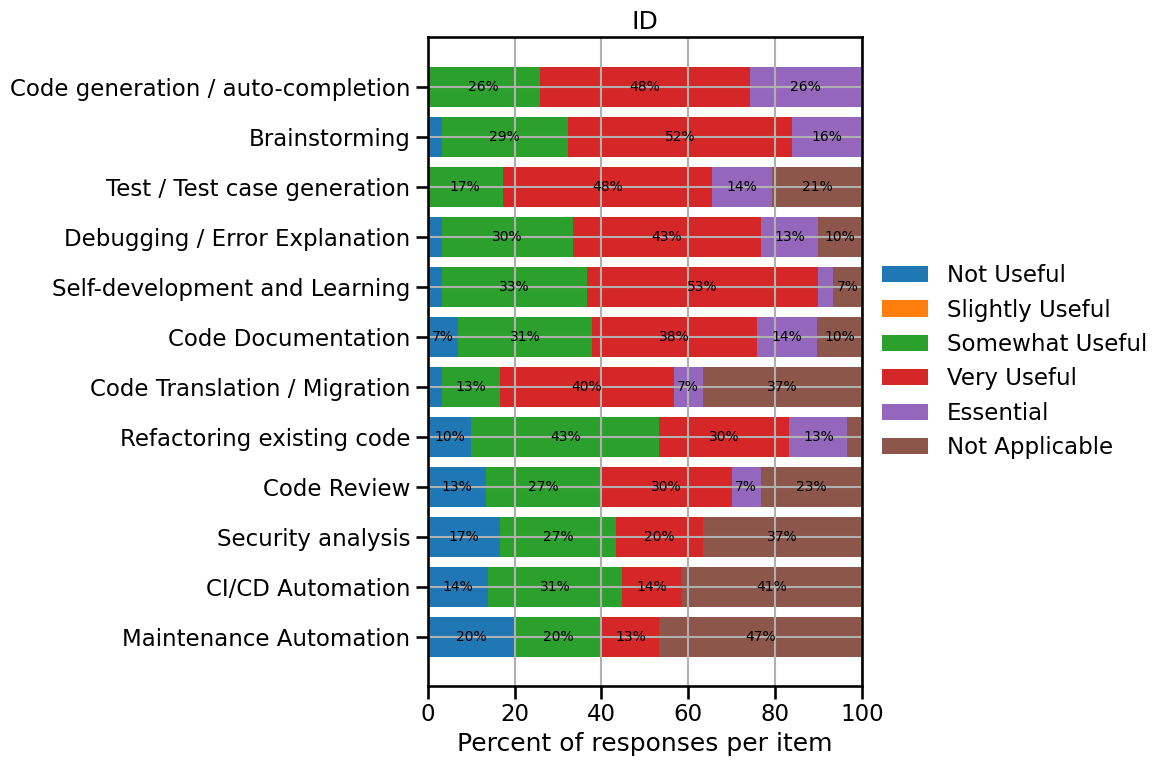

In [22]:
# =========================
# Step 7: Dispatcher for analysis + visualization by question number / sheet
# Assumptions (your structure):
# - RAW_SHEETS contains raw DataFrames loaded with header=None
# - Standard question sheets (Q01–Q09; Q11–Q13; Q16–Q23):
#     row0 = question title
#     rows 1.. = responses
#     col0 = ID, col1 = answer (string; may include ';' for multi-choice)
# - Scaling sheets (Q10, Q14):
#     row0 = question title
#     row1 = item headers (col1..)
#     row2.. = responses (col0 = ID)
#
# Dependencies (from previous steps):
# - Visualization:
#     plot_pie_from_standard_sheet / plot_single_choice_pie (Step 3)
#     plot_multichoice_from_standard_sheet / plot_multichoice_bar (Step 4)
#     plot_scaling_from_raw_sheet / load_scaling_sheet_long (Step 5)
# - Statistics:
#     analyze_question (Step 6)
#     and likert mapping helpers for scaling items
# =========================
from __future__ import annotations

from typing import Dict, Optional, List, Union, Tuple, Literal
import re
import numpy as np
import pandas as pd


# -------------------------
# Configuration
# -------------------------
# Which question sheets are scaling matrices
SCALING_SHEETS = {"Q10", "Q14"}

# Which sheets are empty / ignore
IGNORE_SHEETS = {"Q15"}

# Default multi-choice separator
MULTICHOICE_SEP = ";"

# Default heuristics: treat standard sheet as multi-choice if >= this fraction contain ';'
MULTICHOICE_SEMI_THRESHOLD = 0.20

# Default Likert mapping (customize per your questionnaire vocabulary)
DEFAULT_LIKERT_MAPPING = {
    "Not Useful": 1,
    "Slightly Useful": 2,
    "Somewhat Useful": 3,
    "Very Useful": 4,
    "Essential": 5,
    "Not Applicable": np.nan,
}

DEFAULT_LIKERT_ORDER = [
    "Not Useful",
    "Slightly Useful",
    "Somewhat Useful",
    "Very Useful",
    "Essential",
    "Not Applicable",
]


# -------------------------
# Utilities: question id <-> sheet name
# -------------------------
def qnum_to_sheet(qnum: Union[int, str]) -> str:
    """
    Accepts:
      - 10 -> "Q10"
      - "10" -> "Q10"
      - "Q10" -> "Q10"
      - "q10" -> "Q10"
      - "Q01" -> "Q01"
    """
    if isinstance(qnum, int):
        return f"Q{qnum:02d}" if qnum < 10 else f"Q{qnum}"
    s = str(qnum).strip()
    if re.fullmatch(r"[Qq]\d{1,2}", s):
        s = s.upper()
        # normalize Q1 -> Q01
        n = int(s[1:])
        return f"Q{n:02d}" if n < 10 else f"Q{n}"
    if re.fullmatch(r"\d{1,2}", s):
        n = int(s)
        return f"Q{n:02d}" if n < 10 else f"Q{n}"
    raise ValueError(f"Unrecognized question identifier: {qnum!r}")


def get_question_title(raw_sheets: Dict[str, pd.DataFrame], sheet_name: str) -> str:
    df = raw_sheets[sheet_name]
    title = df.iloc[0, 0] if df.shape[0] > 0 else ""
    return str(title).strip()


def is_scaling_sheet(raw_sheets: Dict[str, pd.DataFrame], sheet_name: str) -> bool:
    """
    Decide if a sheet is scaling.
    Primary: known list (Q10, Q14)
    Fallback heuristic: row1 has multiple headers beyond ID.
    """
    if sheet_name in SCALING_SHEETS:
        return True
    df = raw_sheets[sheet_name]
    # heuristic: if row1 col1 is non-null and there are multiple non-null headers
    if df.shape[0] >= 2 and df.shape[1] >= 3:
        headers = df.iloc[1, 1:]
        nonnull = headers.notna().sum()
        return nonnull >= 2
    return False


def detect_standard_choice_type(
    answers: pd.Series,
    *,
    sep: str = MULTICHOICE_SEP,
    threshold: float = MULTICHOICE_SEMI_THRESHOLD
) -> Literal["single_choice", "multi_choice"]:
    """
    Heuristic: if many answers contain the separator, treat as multi-choice.
    """
    s = answers.dropna().astype(str)
    if s.empty:
        return "single_choice"
    frac_with_sep = (s.str.contains(re.escape(sep))).mean()
    return "multi_choice" if frac_with_sep >= threshold else "single_choice"


# -------------------------
# Extractors for standard sheets
# -------------------------
def extract_standard_answers(
    raw_sheets: Dict[str, pd.DataFrame],
    sheet_name: str
) -> pd.Series:
    """
    Returns Series of answers (col1) from row1.. (excluding title row).
    Index will be respondent IDs if possible.
    """
    df = raw_sheets[sheet_name]
    if df.shape[0] < 2:
        return pd.Series(dtype=object)

    data = df.iloc[1:, [0, 1]].copy()
    data.columns = ["ID", "answer"]
    # Set index to ID when feasible
    if "ID" in data.columns:
        try:
            data["ID"] = pd.to_numeric(data["ID"], errors="coerce")
        except Exception:
            pass
    data = data.dropna(subset=["ID"])
    data = data.set_index("ID")
    return data["answer"]


# -------------------------
# Main dispatcher
# -------------------------
def analyze_and_visualize_question(
    raw_sheets: Dict[str, pd.DataFrame],
    qnum_or_sheet: Union[int, str],
    *,
    # optional grouping (for stats)
    group_series: Optional[pd.Series] = None,
    group_name: str = "Group",
    # visualization toggles
    do_visualize: bool = True,
    do_stats: bool = True,
    # multi-choice visualization params
    multichoice_sep: str = MULTICHOICE_SEP,
    multichoice_max_categories: int = 15,
    # pie params
    pie_max_categories: Optional[int] = None,
    # scaling params
    likert_order: Optional[List[str]] = None,
    likert_mapping: Optional[Dict[str, Union[int, float]]] = None,
) -> Dict[str, object]:
    """
    High-level function:
      - identifies question type from sheet structure
      - extracts title and answers
      - calls appropriate visualization and statistical analysis functions
      - returns a dict of results (tables + test results), and shows plots if enabled
    """
    sheet = qnum_to_sheet(qnum_or_sheet)

    if sheet in IGNORE_SHEETS:
        raise ValueError(f"{sheet} is marked as ignored (empty/no responses).")

    if sheet not in raw_sheets:
        raise KeyError(f"Sheet '{sheet}' not found. Available: {list(raw_sheets.keys())}")

    title = get_question_title(raw_sheets, sheet)

    results: Dict[str, object] = {
        "sheet": sheet,
        "title": title,
    }

    # ---------------------
    # Scaling question
    # ---------------------
    if is_scaling_sheet(raw_sheets, sheet):
        # Use defaults unless provided
        likert_order = likert_order or DEFAULT_LIKERT_ORDER
        likert_mapping = likert_mapping or DEFAULT_LIKERT_MAPPING

        # 1) Visualization (stacked distribution by item)
        if do_visualize:
            # calls Step-5 function
            plot_scaling_from_raw_sheet(
                raw_sheets,
                sheet,
                title=title or f"{sheet} — Scaling question",
                kind="stacked",
                response_order=likert_order,
                likert_mapping=likert_mapping,
                sort_items_by="topbox",
                topbox_responses=[r for r in ["Very Useful", "Essential"] if r in likert_order],
                max_items=None
            )

        # 2) Stats: summary table + optional group comparison per item (advanced)
        # For generality, we return long-format + item distributions.
        long = load_scaling_sheet_long(raw_sheets[sheet], sheet_name=sheet)
        dist_df, numeric_df = scaling_item_summary(
            long,
            response_order=likert_order,
            likert_mapping=likert_mapping,
            include_numeric_summary=True
        )
        results["scaling_long"] = long
        results["scaling_distribution"] = dist_df
        results["scaling_numeric_summary"] = numeric_df

        # Optional: if group_series provided, you can run per-item tests later.
        # (Kept out of default dispatcher to avoid heavy multiple testing silently.)
        return results

    # ---------------------
    # Standard question (single or multi)
    # ---------------------
    answers = extract_standard_answers(raw_sheets, sheet)
    results["answers_preview"] = answers.head(10)

    # Detect single vs multi-choice
    qtype_detected = detect_standard_choice_type(answers, sep=multichoice_sep)
    results["detected_type"] = qtype_detected

    # ---- Visualization
    if do_visualize:
        if qtype_detected == "single_choice":
            # calls Step-3 function
            plot_single_choice_pie(
                answers,
                title=title or f"{sheet} — Single-choice",
                max_categories=pie_max_categories,
            )
        else:
            # calls Step-4 function
            plot_multichoice_bar(
                answers,
                title=title or f"{sheet} — Multi-choice",
                sep=multichoice_sep,
                max_categories=multichoice_max_categories,
                orientation="h",
                value_mode="pct",
            )

    # ---- Statistics
    if do_stats:
        if qtype_detected == "single_choice":
            res = analyze_question(
                question=answers,
                qtype="single_choice",
                title=title or sheet,
                group=group_series
            )
            results["stats"] = res
        else:
            res = analyze_question(
                question=answers,
                qtype="multi_choice",
                title=title or sheet,
                group=group_series,
                sep=multichoice_sep,
                max_options=multichoice_max_categories,
                adjust_p="fdr_bh"
            )
            results["stats"] = res

    return results


# =========================
# Example calls (later)
# =========================
# 1) Single choice example:
# res = analyze_and_visualize_question(RAW_SHEETS, 8)

# 2) Multi choice example:
# res = analyze_and_visualize_question(RAW_SHEETS, 11, multichoice_max_categories=20)

# 3) Scaling example:
res = analyze_and_visualize_question(RAW_SHEETS, 10)